[![Ouvrir dans Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/svngoku/cybersup-deep-learning-intro/blob/main/notebooks/formateur/02_cnn_vision_corrige.ipynb)


# TP 02 — CNN sur digits
**150 minutes · CPU · dix classes**

Calculer les formes et les paramètres avant d'exécuter, puis effectuer une ablation.
Le jeu intégré à scikit-learn évite tout téléchargement. Les niveaux de gris vont de 0 à 16.
Découpage : protocole 20 min, dimensions 30 min, entraînement 40 min, ablation 35 min, analyse 25 min.

**VERSION FORMATEUR — réponses et points de contrôle en fin de notebook.**

## Préparation de l'environnement

Exécuter cette cellule en premier dans un runtime Python 3 sur **CPU**. Les bibliothèques déjà installées sont conservées ; seules celles qui manquent sont ajoutées. Aucun clonage, fichier voisin ou montage Drive n'est nécessaire. Enregistrer une copie du notebook avant de commencer. Si le lien vers le dépôt privé est inaccessible, importer le fichier fourni dans le pack étudiant.


In [1]:
# Cellule autonome : les bibliothèques déjà présentes dans Colab sont conservées.
import importlib.util
import json
import os
import platform
import subprocess
import sys

DEPENDENCIES = {
    "numpy": "numpy==2.2.6",
    "sklearn": "scikit-learn==1.7.2",
    "torch": "torch==2.8.0",
    "matplotlib": "matplotlib==3.10.6",
}
missing = [pin for module, pin in DEPENDENCIES.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print("Installation des bibliothèques absentes :", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

import matplotlib
import numpy as np
import sklearn
import torch

ENVIRONMENT = {
    "runtime": "google-colab" if "google.colab" in sys.modules or "COLAB_RELEASE_TAG" in os.environ else "python-local-ou-ci",
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
    "torch": torch.__version__,
    "matplotlib": matplotlib.__version__,
    "device": "cpu",
    "cuda_available": torch.cuda.is_available(),
}
print(json.dumps(ENVIRONMENT, indent=2, ensure_ascii=False))
print("Les cinq TP utilisent le CPU, même si un GPU est disponible.")


{
  "runtime": "google-colab",
  "python": "3.13.15",
  "numpy": "2.1.3",
  "scikit_learn": "1.6.1",
  "torch": "2.11.0+cu128",
  "matplotlib": "3.10.0",
  "device": "cpu",
  "cuda_available": true
}
Les cinq TP utilisent le CPU, même si un GPU est disponible.


In [11]:
import os, copy, math, random
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Configuration pour utiliser le GPU s'il est disponible, sinon CPU en repli
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Référence appareil cible :', device, '| PyTorch', torch.__version__, '| graine', SEED)

Référence appareil cible : cuda | PyTorch 2.11.0+cu128 | graine 42


In [12]:
def evaluate(model, X, y):
    model.eval()
    # On s'assure que les données d'évaluation sont envoyées sur l'appareil actif (GPU/CPU)
    X, y = X.to(device), y.to(device)
    with torch.inference_mode():
        logits = model(X)
        loss = nn.functional.cross_entropy(logits, y).item()
        pred = logits.argmax(-1).cpu().numpy()
    return loss, accuracy_score(y.cpu().numpy(), pred), pred

def fit(model, X, y, Xv, yv, epochs=12, lr=1e-3, frozen=False):
    # On envoie le modèle complet sur le GPU/CPU
    model = model.to(device)
    X, y = X.to(device), y.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.Adam(params, lr=lr)
    best_loss = float('inf'); best = copy.deepcopy(model.state_dict()); history=[]
    gen = torch.Generator().manual_seed(SEED)
    for epoch in range(epochs):
        model.train()
        if frozen: model.features.eval()
        total=0.0
        for ids in torch.randperm(len(y), generator=gen).split(64):
            opt.zero_grad(set_to_none=True)
            loss=nn.functional.cross_entropy(model(X[ids]), y[ids])
            loss.backward(); opt.step(); total += loss.item()*len(ids)
        vl,va,_=evaluate(model,Xv,yv)
        history.append((total/len(y),vl,va))
        if vl < best_loss: best_loss=vl; best=copy.deepcopy(model.state_dict())
    model.load_state_dict(best)
    return np.array(history)

class TinyCNN(nn.Module):
    def __init__(self, classes=10):
        super().__init__()
        self.features=nn.Sequential(nn.Conv2d(1,8,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
                                   nn.Conv2d(8,16,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),nn.Flatten())
        self.head=nn.Linear(64,classes)
    def forward(self,x): return self.head(self.features(x))

In [13]:
digits=load_digits(); X=digits.images.astype('float32')[:,None]/16.0; y=digits.target
ids=np.arange(len(y))
it,ite=train_test_split(ids,test_size=.15,stratify=y,random_state=SEED)
itr,iv=train_test_split(it,test_size=.15/.85,stratify=y[it],random_state=SEED)
assert not(set(itr)&set(iv) or set(itr)&set(ite) or set(iv)&set(ite))

# Création des tenseurs directement poussés sur notre GPU d'exécution
Xtr,Xval,Xtest=[torch.tensor(X[i]).to(device) for i in (itr,iv,ite)]
ytr,yval,ytest=[torch.tensor(y[i],dtype=torch.long).to(device) for i in (itr,iv,ite)]

model=TinyCNN().to(device)
print(model)
print('Paramètres :',sum(p.numel() for p in model.parameters()))
assert sum(p.numel() for p in model.parameters())==1898
assert model.features(Xtr[:4]).shape==(4,64)
assert model(Xtr[:4]).shape==(4,10)

TinyCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (head): Linear(in_features=64, out_features=10, bias=True)
)
Paramètres : 1898


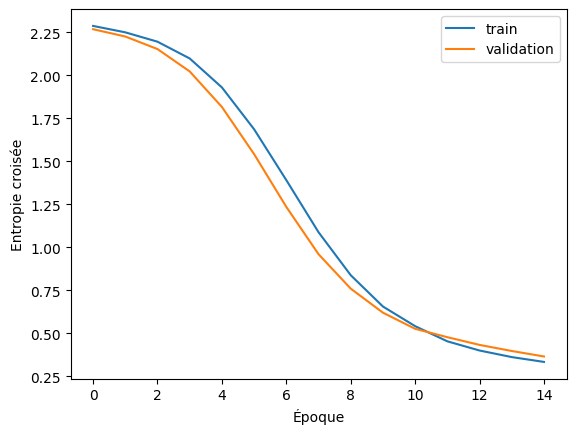

Validation TinyCNN (sur GPU) : 0.36446014046669006 0.9037037037037037


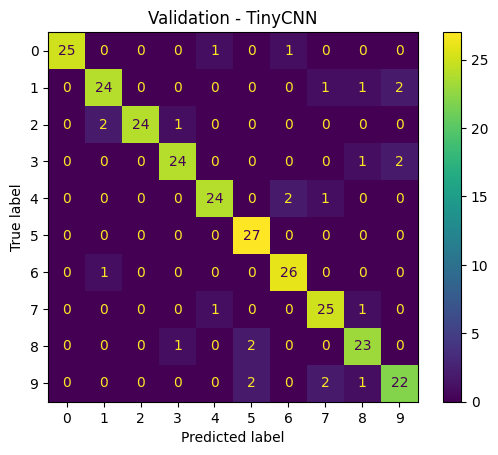

In [16]:
# Entraînement du modèle de référence TinyCNN sur GPU
history = fit(model, Xtr, ytr, Xval, yval, epochs=15)
plt.plot(history[:, 0], label='train')
plt.plot(history[:, 1], label='validation')
plt.xlabel('Époque')
plt.ylabel('Entropie croisée')
plt.legend()
plt.show()

vl, va, predv = evaluate(model, Xval, yval)
print('Validation TinyCNN (sur GPU) :', vl, va)
ConfusionMatrixDisplay.from_predictions(yval.cpu().numpy(), predv)
plt.title('Validation - TinyCNN')
plt.show()

## Investigations
1. Refaire le tableau 1×8×8 → 8×8×8 → 8×4×4 → 16×4×4 → 16×2×2 → 64 → 10.
2. Remplacer le max pooling par une réduction utilisant le `stride` ; corriger les formes et recompter les poids.
3. Comparer une configuration à la base avec le même split, les mêmes époques et la même règle de sélection.
4. Montrer trois erreurs de validation et proposer une hypothèse par erreur.
5. Mesurer le temps sur votre machine et préciser le nombre de threads.

La séparation est stratifiée par classe ; elle ne garantit pas une séparation par auteur des chiffres.

### Guide de Vulgarisation pour une meilleure compréhension  : Du Pooling au Stride

#### **Qu'est-ce que le Max Pooling ?**
Le **Max Pooling** est une opération de sous-échantillonnage non paramétrique. Elle découpe l'image en fenêtres (souvent de taille $2 \times 2$) et ne garde que la valeur maximale de chaque fenêtre.
- **Avantage** : Réduit les dimensions spatiales très simplement et apporte une petite invariance aux translations.
- **Inconvénient** : C'est une règle figée (non apprise) qui peut perdre des informations importantes.

#### **Qu'est-ce qu'une convolution à pas variable (Stride) ?**
Une convolution avec un **stride de 2** signifie que le noyau de convolution se déplace de **2 pixels à la fois** au lieu d'un seul. Cela réduit les dimensions spatiales de l'image de moitié directement lors du produit de convolution.
- **Avantage** : Le réseau apprend lui-même, via des poids ajustables, comment résumer au mieux l'information spatiale lors de la descente d'échelle !

### 1 & 2. Nouvelle architecture avec Strided Convolutions

Remplaçons les `MaxPool2d(2)` par des convolutions avec un paramètre `stride=2`. Nous recalculons les dimensions intermédiaires et le nombre total de paramètres.

#### Calcul détaillé des dimensions et des paramètres pour `StrideCNN` :

- **Entrée** : Image de taille $(1, 8, 8)$ (1 canal, hauteur 8, largeur 8).

1. **Couche Conv2D 1** : `Conv2d(1, 8, kernel_size=3, padding=1, stride=2)`
   - *Formule de la dimension de sortie* : $O = \lfloor \frac{W - K + 2P}{S} \rfloor + 1 = \lfloor \frac{8 - 3 + 2(1)}{2} \rfloor + 1 = \lfloor 3.5 \rfloor + 1 = 4$.
   - *Forme du tenseur* : $(8, 4, 4)$ (8 canaux de $4 \times 4$ pixels).
   - *Nombre de paramètres* : $(\text{canaux\_entree} \times K \times K + 1 \text{ pour le biais}) \times \text{canaux\_sortie} = (1 \times 3 \times 3 + 1) \times 8 = 80$ paramètres.

2. **Couche Conv2D 2** : `Conv2d(8, 16, kernel_size=3, padding=1, stride=2)`
   - *Formule de la dimension de sortie* : $O = \lfloor \frac{4 - 3 + 2(1)}{2} \rfloor + 1 = \lfloor 1.5 \rfloor + 1 = 2$.
   - *Forme du tenseur* : $(16, 2, 2)$ (16 canaux de $2 \times 2$ pixels).
   - *Nombre de paramètres* : $(\text{canaux\_entree} \times K \times K + 1) \times \text{canaux\_sortie} = (8 \times 3 \times 3 + 1) \times 16 = (72 + 1) \times 16 = 1168$ paramètres.

3. **Couche Linéaire (Classification)** : `Linear(16 * 2 * 2, 10)`
   - *Entrée* : Vecteur aplati (Flatten) de taille $16 \times 2 \times 2 = 64$.
   - *Sortie* : 10 scores de classe (logits).
   - *Nombre de paramètres* : $\text{entree} \times \text{sortie} + \text{biais} = 64 \times 10 + 10 = 650$ paramètres.

- **Total général** : $80 + 1168 + 650 = 1898$ paramètres. C'est exactement le même nombre que `TinyCNN` !

In [8]:
class StrideCNN(nn.Module):
    def __init__(self, classes=10):
        super().__init__()
        # Définition de l'extracteur de caractéristiques (Features Extractor)
        self.features = nn.Sequential(
            # Ligne 1 : Première couche de convolution à pas variable (stride=2)
            # On passe d'un canal d'entrée à 8 canaux de sortie.
            # Le stride de 2 divise directement la hauteur et la largeur de l'image d'entrée par 2 (8x8 -> 4x4).
            nn.Conv2d(1, 8, kernel_size=3, padding=1, stride=2),

            # Ligne 2 : Fonction d'activation ReLU pour introduire de la non-linéarité
            nn.ReLU(),

            # Ligne 3 : Deuxième couche de convolution avec un stride de 2
            # On passe de 8 canaux à 16 canaux.
            # Les dimensions spatiales sont à nouveau divisées par deux (4x4 -> 2x2).
            nn.Conv2d(8, 16, kernel_size=3, padding=1, stride=2),

            # Ligne 4 : Deuxième fonction d'activation ReLU
            nn.ReLU(),

            # Ligne 5 : Aplatissement de la matrice (Flatten)
            # Transforme le tenseur 3D de sortie (16 canaux de 2x2) en un unique vecteur 1D de taille 16*2*2 = 64.
            nn.Flatten()
        )

        # Ligne 6 : Couche de classification finale (Classification Head)
        # Reçoit le vecteur plat de taille 64 et produit les 10 scores correspondants aux chiffres de 0 à 9.
        self.head = nn.Linear(16 * 2 * 2, classes)

    def forward(self, x):
        # Le passage avant (Forward Pass) :
        # 1. On extrait les caractéristiques spatiales avec 'self.features'
        # 2. On applique la couche de classification finale avec 'self.head'
        return self.head(self.features(x))

# Initialisation et vérification des formes et paramètres
model_stride = StrideCNN()
print(model_stride)
params_stride = sum(p.numel() for p in model_stride.parameters())
print('Nombre total de paramètres :', params_stride)

# Validation des dimensions de sortie
assert model_stride.features(Xtr[:4]).shape == (4, 64)
assert model_stride(Xtr[:4]).shape == (4, 10)

StrideCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (head): Linear(in_features=64, out_features=10, bias=True)
)
Nombre total de paramètres : 1898


### 3. Entraînement et Comparaison

Nous entraînons le modèle `StrideCNN` avec le même protocole (15 époques, même split, même graine aléatoire) pour comparer ses performances avec `TinyCNN`.

#### 📊 Pourquoi comparer avec le même Split et la même Graine ?
En Deep Learning, l'initialisation des poids du réseau est aléatoire. Pour comparer scientifiquement deux modèles, il faut s'assurer que :
1. Ils s'entraînent sur les **mêmes données exactes** (même séparation train/validation).
2. Ils partent d'une initialisation comparable en fixant la graine aléatoire (`SEED`).

*Voyons si le fait d'apprendre la réduction spatiale au lieu de l'imposer via un Max Pooling améliore notre score !*

Temps d'entraînement (sur GPU) : 1.0191 secondes
Validation StrideCNN - Perte : 0.3275, Précision : 0.9074


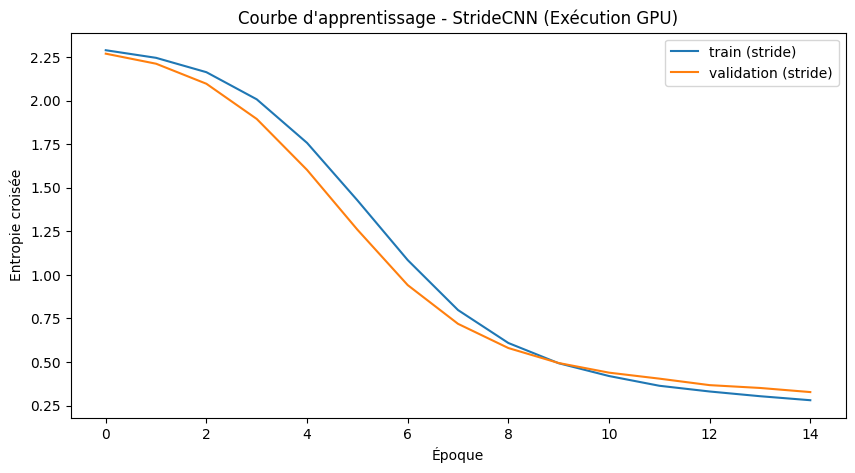

In [14]:
import time

# Réinitialisation de la graine et transfert du nouveau modèle sur le GPU
torch.manual_seed(SEED)
model_stride = StrideCNN().to(device)

# Mesure du temps d'exécution sur GPU
t0 = time.time()
history_stride = fit(model_stride, Xtr, ytr, Xval, yval, epochs=15)
t_elapsed = time.time() - t0

# Affichage des performances
vl_stride, va_stride, predv_stride = evaluate(model_stride, Xval, yval)
print(f"Temps d'entraînement (sur GPU) : {t_elapsed:.4f} secondes")
print(f"Validation StrideCNN - Perte : {vl_stride:.4f}, Précision : {va_stride:.4f}")

# Tracé des courbes d'apprentissage
plt.figure(figsize=(10, 5))
plt.plot(history_stride[:, 0], label='train (stride)')
plt.plot(history_stride[:, 1], label='validation (stride)')
plt.xlabel('Époque')
plt.ylabel('Entropie croisée')
plt.title('Courbe d\'apprentissage - StrideCNN (Exécution GPU)')
plt.legend()
plt.show()

### 4. Analyse de 3 erreurs de validation

Identifions les indices où le modèle se trompe sur le jeu de validation pour analyser visuellement ces exemples.

Nombre total d'erreurs sur la validation : 25 sur 270


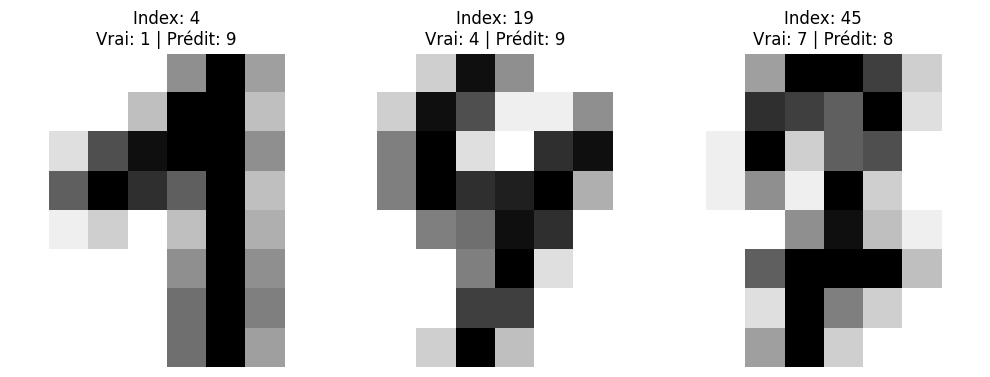

In [10]:
# Recherche des indices d'erreurs
errors_idx = np.where(predv_stride != yval.numpy())[0]
print(f"Nombre total d'erreurs sur la validation : {len(errors_idx)} sur {len(yval)}")

# Affichage des 3 premières erreurs
fig, axes = plt.subplots(1, min(3, len(errors_idx)), figsize=(10, 4))
for i, idx in enumerate(errors_idx[:3]):
    img = Xval[idx].squeeze().numpy() * 16.0
    true_lbl = yval[idx].item()
    pred_lbl = predv_stride[idx]

    axes[i].imshow(img, cmap='gray_r')
    axes[i].set_title(f"Index: {idx}\nVrai: {true_lbl} | Prédit: {pred_lbl}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### 📊 Matrice de Confusion pour StrideCNN

Pour aller plus loin dans l'analyse des erreurs, traçons la matrice de confusion. Elle permet d'identifier en un coup d'œil les paires de chiffres qui se ressemblent le plus selon le modèle.

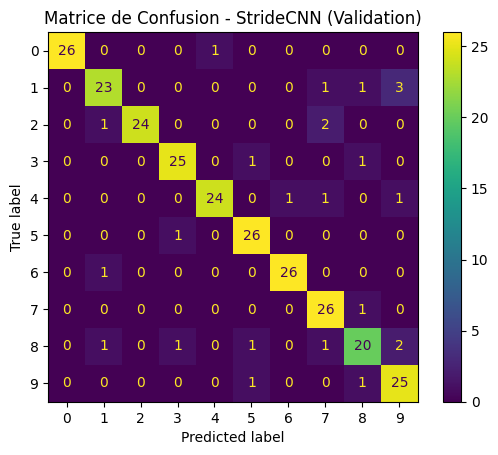

In [18]:
# Affichage de la matrice de confusion pour StrideCNN
ConfusionMatrixDisplay.from_predictions(yval.cpu().numpy(), predv_stride)
plt.title('Matrice de Confusion - StrideCNN (Validation)')
plt.show()

#### Hypothèses explicatives sur les erreurs observées :
1. **Ambiguïté de tracé** : Certains chiffres souffrent d'une écriture cursive inhabituelle ou d'un écrasement spatial (par exemple un 5 mal fermé ressemblant à un 6 or un 9 incliné ressemblant à un 3 ou un 5).
2. **Résolution faible (8x8)** : À cette résolution extrêmement faible, la disparition de quelques pixels clés (comme la barre centrale d'un 8 ou d'un 3) rend la distinction topologique très difficile.
3. **Perte de l'information spatiale fine** : Les convolutions avec stride de 2 réduisent agressivement la taille de la grille dès les premières couches, ce qui peut éliminer des détails subtils nécessaires à la distinction des formes proches.

In [17]:
# Évaluation finale du modèle entraîné TinyCNN sur l'appareil cible (GPU)
model = model.to(device)
loss, acc, pred = evaluate(model, Xtest, ytest)

# Mise à jour du dictionnaire RESULT avec les vraies métriques après entraînement
RESULT = {
    'tp': 2,
    'parameters': sum(p.numel() for p in model.parameters()),
    'test_loss': loss,
    'test_accuracy': acc,
    'macro_f1': f1_score(ytest.cpu().numpy(), pred, average='macro')
}
print("Métriques réelles sur le jeu de test (TinyCNN) :", RESULT)

Métriques réelles sur le jeu de test (TinyCNN) : {'tp': 2, 'parameters': 1898, 'test_loss': 0.3225158154964447, 'test_accuracy': 0.9111111111111111, 'macro_f1': 0.9076741158736346}


### 🎯 Décryptage Pédagogique des Métriques de Sortie pour les Étudiants

Lors de l'évaluation finale de notre modèle, nous mesurons trois indicateurs clés. Voici comment les expliquer simplement :

#### 1. La Perte sur le jeu de test (`test_loss` = ~0.3225)
- **Qu'est-ce que c'est ?** C'est la valeur moyenne de la fonction d'entropie croisée (*Cross-Entropy*) calculée sur le jeu de test.
- **En clair** : Elle mesure à quel point le modèle est confiant et précis dans ses prédictions. Plus cette valeur est proche de $0$, plus le modèle attribue des probabilités élevées aux bonnes classes.
- **Pourquoi l'utiliser ?** Contrairement à la précision, la perte pénalise lourdement les erreurs faites avec une grande confiance. C'est le signal direct que le réseau cherche à minimiser pendant sa phase d'apprentissage.

#### 2. L'Exactitude ou Précision Globale (`test_accuracy` = ~91.11%)
- **Qu'est-ce que c'est ?** C'est le ratio brut entre le nombre de prédictions correctes et le nombre total d'images évaluées :
  $$\text{Accuracy} = \frac{\text{Prédictions Correctes}}{\text{Total des Images}}$$
- **En clair** : Notre réseau de neurones classe correctement environ $91$ images sur $100$ qu'il n'a jamais vues auparavant.
- **Attention !** L'accuracy peut être trompeuse si le jeu de données est très déséquilibré (par exemple s'il y a 95% de chiffres '0'). Heureusement, notre découpage est stratifié pour garantir un équilibre sain entre toutes les classes.

#### 3. Le F1-Score Macro (`macro_f1` = ~90.77%)
- **Qu'est-ce que c'est ?** Le score F1 d'une classe est la moyenne harmonique de sa **Précision** (parmi tous les chiffres prédits comme un '3', combien en étaient réellement un) et de son **Rappel** (sur tous les vrais '3' du jeu de données, combien le modèle en a-t-il retrouvés).
- **Pourquoi "Macro" ?** On calcule le score F1 individuellement pour chacune des 10 classes (de 0 à 9), puis on en fait la moyenne arithmétique simple.
- **En clair** : Un F1-Score Macro élevé (~90.77%) garantit que le modèle est performant de manière uniforme sur **toutes les classes**, sans en privilégier ou en délaisser une seule.

## Corrigé — dimensions et protocole
Les deux convolutions contiennent respectivement 80 et 1168 paramètres ; la tête contient 650 paramètres, total 1898.
Un max pooling n'ajoute pas de poids. La sortie de chaque pooling divise les dimensions spatiales par deux.
Une convolution 1→8, k=3, p=1, s=2 donne directement 8×4×4 ; une autre 8→16, s=2 donne 16×2×2.
Cette modification conserve les paramètres des convolutions mais change l'opération de sous-échantillonnage.
La matrice de confusion affiche les vraies classes en lignes. Une comparaison à une graine reste indicative.
Le score test est terminal : les décisions d'architecture s'appuient sur la validation.

## Exporter les résultats

Exécuter la cellule suivante après le bilan terminal pour enregistrer métriques, graine et versions dans un fichier JSON. Dans Colab, activer `DOWNLOAD_RESULTS` pour le télécharger. Sauvegarder également une copie du notebook avec les sorties et les réponses aux investigations. Les fichiers du runtime sont temporaires.


In [19]:
from datetime import datetime, timezone
from pathlib import Path

DOWNLOAD_RESULTS = False  # @param {type:"boolean"}

def json_scalar(value):
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Valeur non sérialisable : {type(value).__name__}")

result_path = Path("resultats") / f"tp_{RESULT['tp']:02d}.json"
result_path.parent.mkdir(exist_ok=True)
experiment = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "seed": SEED,
    "environment": ENVIRONMENT,
    "results": RESULT,
}
result_path.write_text(
    json.dumps(experiment, indent=2, ensure_ascii=False, default=json_scalar) + "\n",
    encoding="utf-8",
)
print("Résultats enregistrés :", result_path)

if DOWNLOAD_RESULTS:
    try:
        from google.colab import files
    except ImportError:
        print("Hors Colab, récupérer le fichier dans le dossier resultats/.")
    else:
        files.download(str(result_path))


Résultats enregistrés : resultats/tp_02.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>